# Exam Scheduling — Experiment Notebook

All algorithms run via C++for speed.  
Falls back to Python automatically if C++ isn't compiled.

**Workflow:** Edit config -> Run experiments -> View tables & plots -> Export


In [13]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
from IPython.display import display, HTML

from data.parser import parse_itc2007_exam
from data.generator import generate_synthetic, write_itc2007_format
from algorithms.cpp_bridge import run_solver
from utils.results_logger import ResultsLogger
from utils.plotting import *

try:
    from algorithms.ip_solver import solve_ip
    HAS_IP = True
except ImportError:
    HAS_IP = False

logger = ResultsLogger("results/run_log.jsonl")
print(f"Existing records: {len(logger.load_all())}")
print("Ready. All solvers route through C++ binary.")

Existing records: 0
Ready. All solvers route through C++ binary.


## Config

In [16]:
DATASETS = {
    "exam_comp_set4": "datasets/exam_comp_set4.exam",
    "exam_comp_set5": "datasets/exam_comp_set5.exam",
    "exam_comp_set7": "datasets/exam_comp_set7.exam",
}

# Which C++ algorithms to run ("greedy", "tabu", "hho", or "all")
ALGO = "all"

# Algorithm parameters
TABU_ITERS     = 1000
TABU_TENURE    = 20
TABU_PATIENCE  = 500
HHO_POP        = 30
HHO_ITERS      = 150
SEED           = 42
NUM_TRIALS     = 3   # Increase for stat avg

# IP solver (Python, only for small instances)
RUN_IP         = False
IP_TIME_LIMIT  = 600

VERBOSE = True


## Load Datasets

In [14]:
problems = {}
for name, path in DATASETS.items():
    if os.path.isfile(path):
        problems[name] = parse_itc2007_exam(path)
        p = problems[name]
        print(f"{name}: {p.num_exams()} exams, {p.num_periods()} periods, "
              f"{p.num_rooms()} rooms, {p.num_students()} students, "
              f"density={p.conflict_density():.3f}")
    else:
        print(f"SKIP: {path} not found")
print(f"\nLoaded {len(problems)} dataset(s)")

exam_comp_set4: 273 exams, 21 periods, 1 rooms, 4421 students, density=0.150
exam_comp_set5: 1018 exams, 42 periods, 3 rooms, 8719 students, density=0.009
exam_comp_set7: 1096 exams, 80 periods, 15 rooms, 13795 students, density=0.019

Loaded 3 dataset(s)


## Run Experiments

In [ ]:
session_records = []

for ds_name, ds_path in DATASETS.items():
    if ds_name not in problems:
        continue
    problem = problems[ds_name]
    print(f"\n{'='*60}\n  {ds_name} ({problem.num_exams()} exams)\n{'='*60}")

    for trial in range(NUM_TRIALS):
        seed = SEED + trial * 1000

        # C++ algorithms
        results = run_solver(
            ds_path, algo=ALGO,
            tabu_iters=TABU_ITERS, tabu_tenure=TABU_TENURE,
            tabu_patience=TABU_PATIENCE, hho_pop=HHO_POP,
            hho_iters=HHO_ITERS, seed=seed, verbose=VERBOSE,
        )

        for algo_name, r in results.items():
            config = {"tabu_iters": TABU_ITERS, "tabu_tenure": TABU_TENURE,
                      "hho_pop": HHO_POP, "hho_iters": HHO_ITERS, "seed": seed}
            rec = logger.log_run(ds_name, problem, r, config=config, trial=trial)
            session_records.append(rec)
            ev = r['evaluation']
            feasible = ev.feasible if hasattr(ev, 'feasible') else ev.is_feasible
            soft = ev.soft if hasattr(ev, 'soft') else ev.soft_penalty
            hard = ev.hard if hasattr(ev, 'hard') else ev.hard_violations
            print(f"  [{algo_name:<12}] t={trial}  feasible={feasible}  "
                  f"hard={hard}  soft={soft:>8}  time={r['runtime']:.3f}s")

        # ── IP solver (Python, optional) ──
        if RUN_IP and HAS_IP and problem.num_exams() <= 300:
            r = solve_ip(problem, time_limit=IP_TIME_LIMIT, verbose=VERBOSE)
            rec = logger.log_run(ds_name, problem, r,
                config={"ip_time_limit": IP_TIME_LIMIT}, trial=trial)
            session_records.append(rec)

print(f"\nLogged {len(session_records)} records this session")
print(f"Total in log: {len(logger.load_all())}")


## Results Table

In [ ]:
df = logger.to_dataframe()

summary = df.groupby(['dataset', 'algorithm']).agg(
    runs=('feasible', 'count'),
    feasible_pct=('feasible', lambda x: f"{x.mean()*100:.0f}%"),
    hard_mean=('hard_violations', 'mean'),
    soft_mean=('soft_penalty', 'mean'),
    soft_std=('soft_penalty', 'std'),
    soft_min=('soft_penalty', 'min'),
    runtime_mean=('runtime', 'mean'),
).round(2).reset_index()

display(HTML("<h3>All Logged Runs</h3>"))
display(summary)


## Aggregated Results & Export

In [ ]:
agg_path = logger.save_aggregated()
csv_path = logger.to_csv()
print(f"Aggregated JSON: {agg_path}")
print(f"Full CSV: {csv_path}")

agg_df = logger.aggregate_to_dataframe()
cols = ['algorithm','dataset','count','feasible_rate',
        'runtime_mean','runtime_std','soft_penalty_mean','soft_penalty_std','soft_penalty_min']
display(agg_df[[c for c in cols if c in agg_df.columns]].round(2))

## Visualizations

In [ ]:
# Per-dataset soft penalty + runtime bars
for ds in df['dataset'].unique():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_algorithm_comparison(df, dataset=ds, metric='soft_penalty', ax=axes[0])
    plot_algorithm_comparison(df, dataset=ds, metric='runtime', ax=axes[1])
    fig.suptitle(ds, fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [ ]:
# Soft constraint breakdown
for ds in df['dataset'].unique():
    plot_soft_breakdown(df, dataset=ds)
    plt.show()

In [ ]:
# Quality vs time scatter
for ds in df['dataset'].unique():
    plot_runtime_vs_quality(df, dataset=ds)
    plt.show()

In [ ]:
# Cross-dataset heatmap + feasibility
if len(df['dataset'].unique()) > 1:
    plot_multi_dataset_heatmap(df, metric='soft_penalty')
    plt.show()
    plot_feasibility_rates(df)
    plt.show()

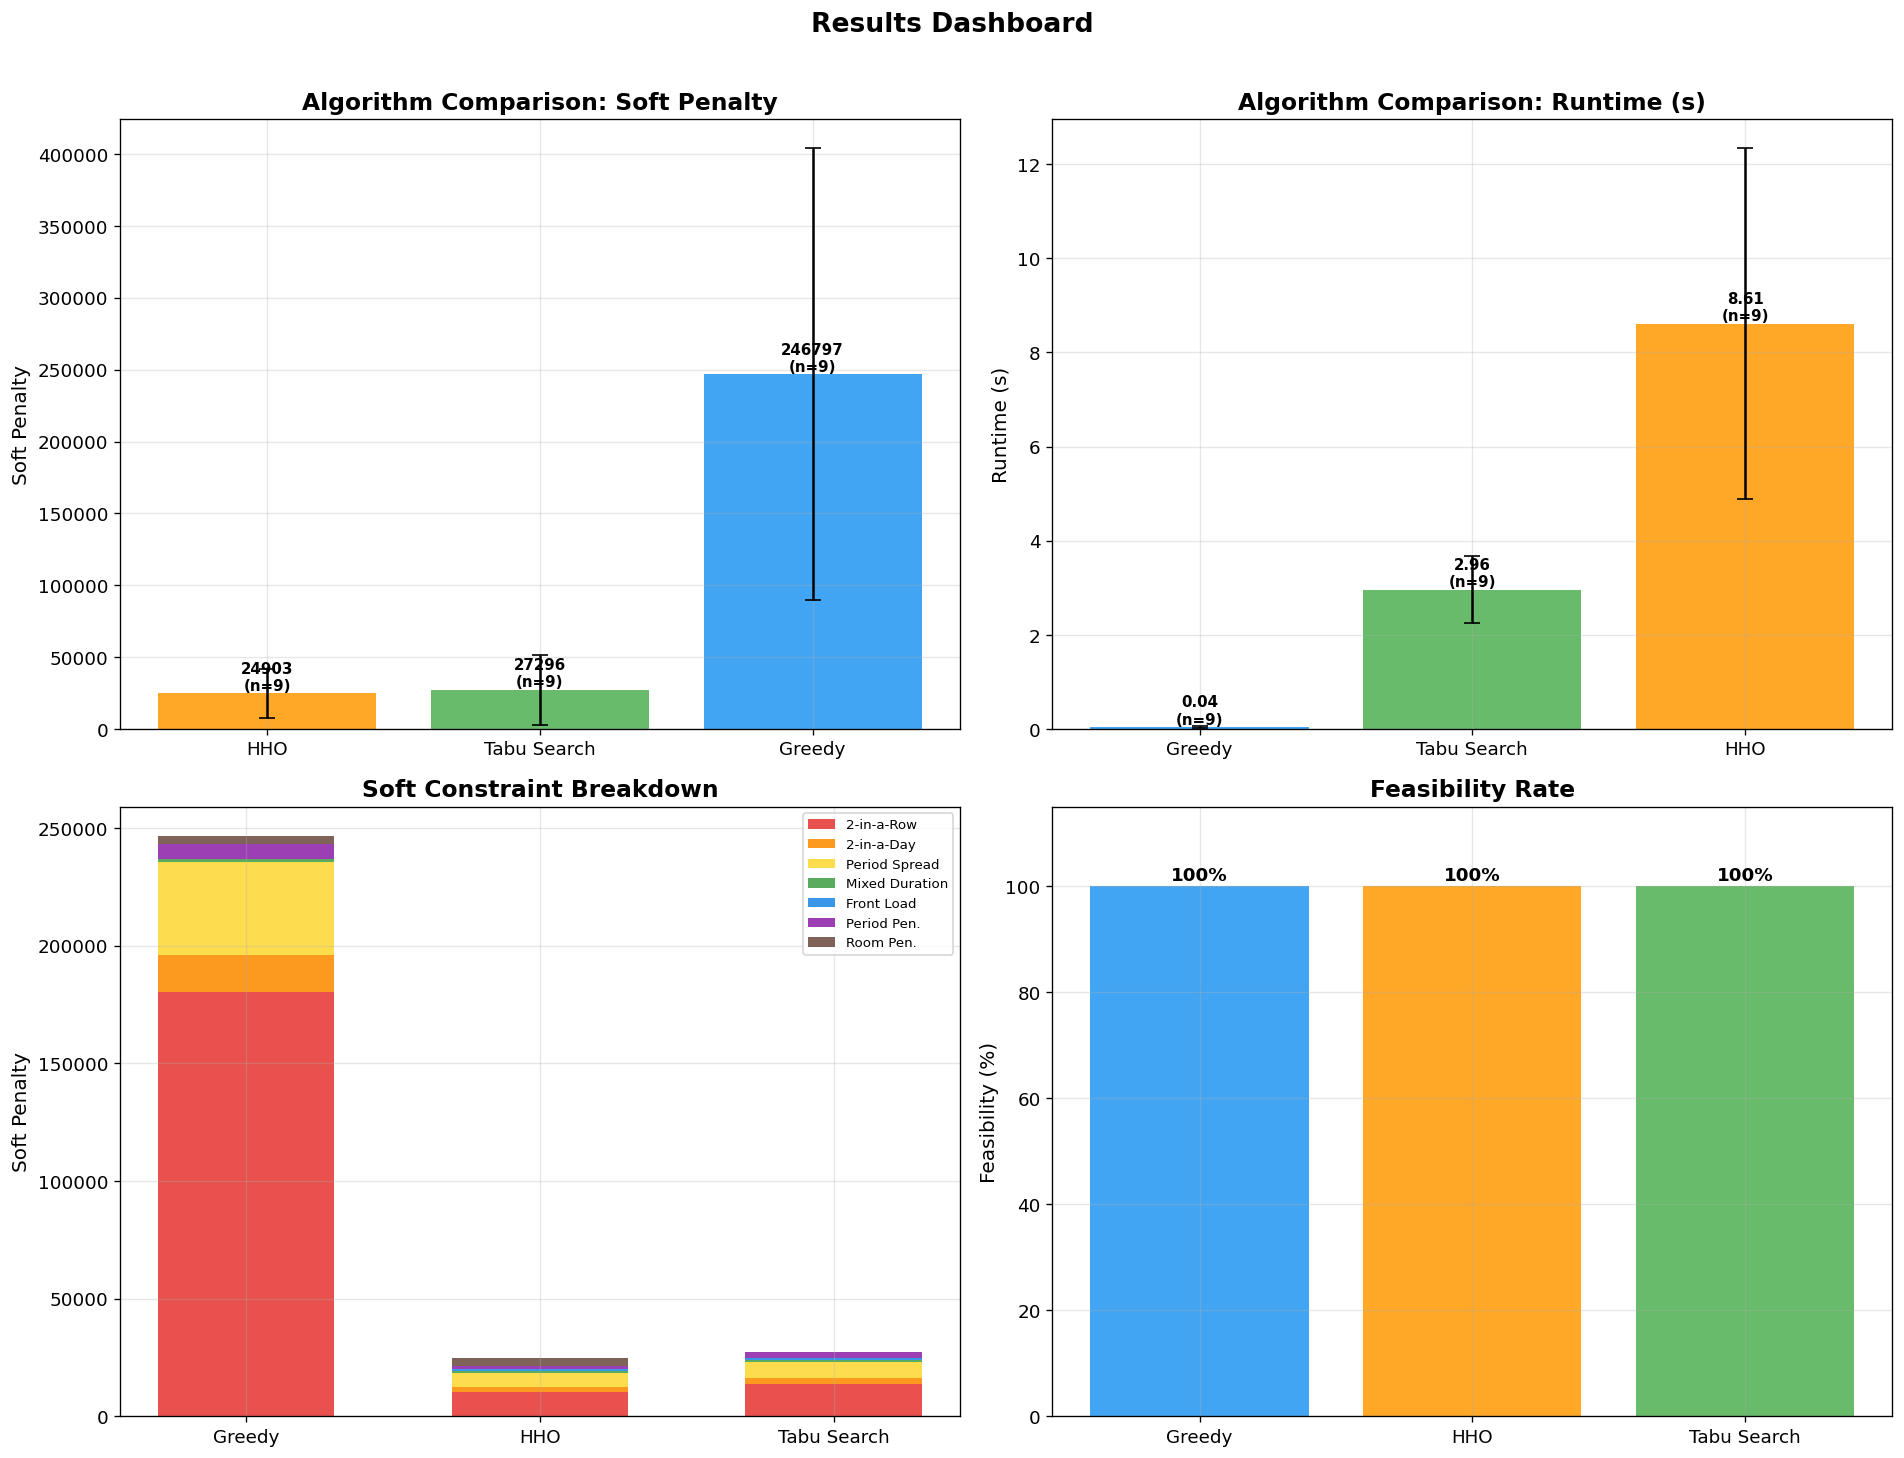

In [22]:
# Full dashboard
plot_summary_dashboard(df)
plt.show()

In [ ]:
# Save all plots
generate_all_plots(logger, output_dir="results")

## Parameter Sweep — Tabu Iterations

Runs tabu with increasing iteration counts to study convergence.


In [ ]:
SWEEP_DATASET = list(DATASETS.keys())[0]
SWEEP_PATH    = DATASETS[SWEEP_DATASET]
PARAM_VALUES  = [100, 250, 500, 1000, 2000, 3000]
SWEEP_TRIALS  = 3

sweep_records = []
problem = problems[SWEEP_DATASET]

for iters in PARAM_VALUES:
    for trial in range(SWEEP_TRIALS):
        seed = 42 + trial * 1000
        results = run_solver(
            SWEEP_PATH, algo="tabu",
            tabu_iters=iters, tabu_patience=min(iters, 500),
            seed=seed, verbose=False,
        )
        for name, r in results.items():
            rec = logger.log_run(SWEEP_DATASET, problem, r,
                config={"tabu_iters": iters, "seed": seed},
                trial=trial, notes=f"sweep_iters_{iters}")
            sweep_records.append(rec)
        print(f"  iters={iters} t={trial}: soft={rec['soft_penalty']} time={rec['runtime']:.2f}s")

# Plot
sdf = pd.DataFrame(sweep_records)
sdf['cfg_tabu_iters'] = sdf['config'].apply(lambda c: c.get('tabu_iters', 0))
plot_parameter_sensitivity(sdf, 'cfg_tabu_iters', metric='soft_penalty', algorithm='Tabu Search')
plt.show()


## Scaling Study — Synthetic Instances

Generates competition-level instances of increasing size. Uses presets:
`"easy"`, `"medium"`, `"hard"`, `"competition"`.


In [ ]:
SIZES  = [50, 100, 200, 500]
PRESET = "medium"   # Try "competition" for ITC2007-like hardness

os.makedirs("datasets", exist_ok=True)
scale_records = []

for n in SIZES:
    # Generate + write .exam file
    problem = generate_synthetic(num_exams=n, preset=PRESET, seed=42+n)
    exam_path = f"datasets/synthetic_{PRESET}_{n}.exam"
    write_itc2007_format(problem, exam_path)

    for trial in range(2):
        seed = 42 + trial * 1000
        results = run_solver(exam_path, algo="all",
            tabu_iters=min(2000, n*5), hho_iters=min(200, n),
            hho_pop=min(30, max(10, n//10)),
            seed=seed, verbose=False)

        for name, r in results.items():
            rec = logger.log_run(f"synthetic_{n}", problem, r,
                config={"preset": PRESET, "seed": seed},
                trial=trial, notes=f"scaling_{PRESET}")
            scale_records.append(rec)

    print(f"  n={n}: {len(results)} algos done")

sdf = pd.DataFrame(scale_records)
plot_scaling(sdf, x_col='num_exams', y_col='runtime')
plt.title('Runtime Scaling by Algorithm', fontweight='bold')
plt.show()

plot_scaling(sdf, x_col='num_exams', y_col='soft_penalty')
plt.title('Solution Quality vs Problem Size', fontweight='bold')
plt.show()

## Custom Experiment

In [ ]:
# Template: uncomment and edit 
#
# # Run a single algorithm with custom params
# results = run_solver("datasets/exam_comp_set4.exam", algo="tabu",
#                       tabu_iters=5000, tabu_patience=1000, seed=123, verbose=True)
#
# # Log it
# p = problems["exam_comp_set4"]
# for name, r in results.items():
#     rec = logger.log_run("exam_comp_set4", p, r,
#         config={"tabu_iters": 5000}, notes="custom experiment")
#     print(f"{name}: soft={rec['soft_penalty']} time={rec['runtime']:.2f}s")
#
# # Generate a hard synthetic instance
# problem = generate_synthetic(num_exams=300, preset="competition", seed=99)
# write_itc2007_format(problem, "datasets/custom_hard.exam")
# results = run_solver("datasets/custom_hard.exam", algo="all", verbose=True)

## Utilities

In [ ]:
# Log stats
if os.path.isfile(logger.filepath):
    n = len(logger.load_all())
    kb = os.path.getsize(logger.filepath) / 1024
    print(f"Log: {n} records, {kb:.1f} KB")

# Uncomment to clear and start fresh:
#logger.clear(); print("Log cleared")

Log: 47 records, 34.9 KB
Log cleared
